# qk_keep Experiment Comparison
This notebook aggregates models under `qk_experiments/` and compares basic metrics.
Run the benchmark cell if you want local timing stats.


In [1]:
from pathlib import Path
import pandas as pd
import json

BASE_DIR = Path('qk_experiments')
MODEL_DIRS = sorted(BASE_DIR.glob('model_keep_*'))
ZIP_FILES = {p.stem: p for p in BASE_DIR.glob('submit_keep_*.zip')}
MODEL_DIRS


[WindowsPath('qk_experiments/model_keep_0_3_26'),
 WindowsPath('qk_experiments/model_keep_0_4_25'),
 WindowsPath('qk_experiments/model_keep_0_4_27'),
 WindowsPath('qk_experiments/model_keep_0_5_26')]

In [2]:
def size_gb(path: Path):
    if not path.exists():
        return None
    return round(path.stat().st_size / (1024**3), 3)

rows = []
for mdir in MODEL_DIRS:
    name = mdir.name.replace('model_', '')
    zip_path = ZIP_FILES.get('submit_' + name)
    rows.append({
        'name': name,
        'model_dir': str(mdir),
        'zip': str(zip_path) if zip_path else None,
        'zip_gb': size_gb(zip_path) if zip_path else None,
    })

df = pd.DataFrame(rows).sort_values('name')
df


,name,model_dir,zip,zip_gb
0,keep_0_3_26,qk_experiments\model_keep_0_3_26,qk_experiments\submit_keep_0_3_26.zip,1.068
1,keep_0_4_25,qk_experiments\model_keep_0_4_25,qk_experiments\submit_keep_0_4_25.zip,1.068
2,keep_0_4_27,qk_experiments\model_keep_0_4_27,qk_experiments\submit_keep_0_4_27.zip,1.068
3,keep_0_5_26,qk_experiments\model_keep_0_5_26,qk_experiments\submit_keep_0_5_26.zip,1.068


In [3]:
lb = {
    
}

def lookup(name, key):
    return lb.get(name, {}).get(key)

df['lb_score'] = df['name'].apply(lambda n: lookup(n, 'score'))
df['time_min'] = df['name'].apply(lambda n: lookup(n, 'time_min'))
df


,name,model_dir,zip,zip_gb,lb_score,time_min
0,keep_0_3_26,qk_experiments\model_keep_0_3_26,qk_experiments\submit_keep_0_3_26.zip,1.068,None,None
1,keep_0_4_25,qk_experiments\model_keep_0_4_25,qk_experiments\submit_keep_0_4_25.zip,1.068,None,None
2,keep_0_4_27,qk_experiments\model_keep_0_4_27,qk_experiments\submit_keep_0_4_27.zip,1.068,None,None
3,keep_0_5_26,qk_experiments\model_keep_0_5_26,qk_experiments\submit_keep_0_5_26.zip,1.068,None,None


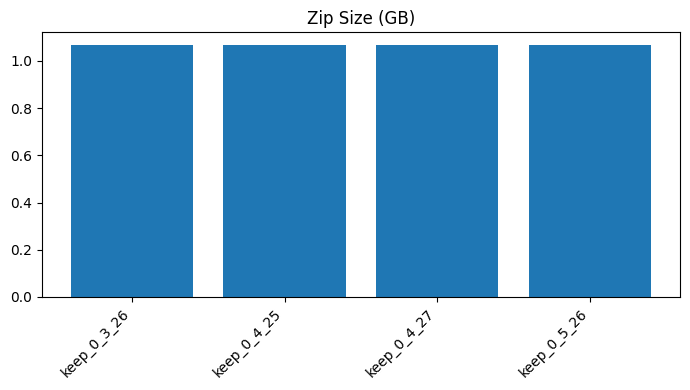

In [4]:
# Optional: simple visualization
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=['zip_gb'])
plt.figure(figsize=(7, 4))
plt.bar(plot_df['name'], plot_df['zip_gb'])
plt.title('Zip Size (GB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Local benchmark + auto scoring
import time
import re
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_NEW_TOKENS = 32

PROMPTS = [
    {
        'id': 'seq',
        'type': 'numeric',
        'prompt': '다음 수열의 다음 항을 추론해줘: 2, 6, 12, 20, 30, ?',
        'answer': 42,
    },
    {
        'id': 'code',
        'type': 'numeric',
        'prompt': '다음 파이썬 코드의 출력과 이유를 설명해줘:\nprint([i*i for i in range(5)][-2])',
        'answer': 9,
    },
    {
        'id': 'math',
        'type': 'numeric',
        'prompt': '정수 x, y가 x+y=17, x-y=5일 때 x*y는?',
        'answer': 72,
    },

]


def load_tokenizer(model_dir):
    try:
        return AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True, fix_mistral_regex=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)

def finish_reason(gen_tokens, max_new_tokens):
    return 'length' if gen_tokens >= max_new_tokens else 'stop'

def extract_first_int(text):
    m = re.search(r'-?\d+', text)
    return int(m.group(0)) if m else None

def score_output(item, text):
    if item['type'] == 'numeric':
        val = extract_first_int(text)
        return 1 if val == item['answer'] else 0
    if item['type'] == 'format':
        words = re.findall(r'[A-Za-z0-9?-?]+', text)
        word_count = len(words)
        comma_ok = text.count(',') == 1
        nums = re.findall(r'\d+', text)
        num_ok = len(nums) == 2
        len_ok = 15 <= word_count <= 20
        return 1 if (comma_ok and num_ok and len_ok) else 0
    return None


c:\Users\FORYOUCOM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:

def bench_model(model_dir):
    tokenizer = load_tokenizer(model_dir)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        dtype=torch.bfloat16 if DEVICE=='cuda' else None,
    )
    model.to(DEVICE)

    times = []
    gen_tokens_list = []
    finish_counts = {'length': 0, 'stop': 0}
    scores = []

    for item in PROMPTS:
        inputs = tokenizer(item['prompt'], return_tensors='pt').to(DEVICE)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            return_dict_in_generate=True,
            output_scores=False,
        )
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t1 = time.time()

        sequences = out.sequences
        gen_tokens = sequences.shape[-1] - inputs['input_ids'].shape[-1]
        gen_tokens_list.append(gen_tokens)
        times.append(t1 - t0)

        reason = finish_reason(gen_tokens, MAX_NEW_TOKENS)
        finish_counts[reason] += 1

        text = tokenizer.decode(sequences[0], skip_special_tokens=True)
        s = score_output(item, text)
        scores.append(s)

    total_time = sum(times)
    total_tokens = sum(gen_tokens_list)
    n = max(len(gen_tokens_list), 1)

    s = pd.Series(gen_tokens_list)
    # scoring: ignore None (skip)
    score_vals = [x for x in scores if x is not None]
    score_total = sum(score_vals) if score_vals else 0
    score_count = len(score_vals)
    score_ratio = round(score_total / score_count, 3) if score_count else None

    return {
        'test_time_sec': round(total_time, 3),
        'out_tok_mean': round(total_tokens / n, 3),
        'out_tok_p50': float(s.quantile(0.50)),
        'out_tok_p90': float(s.quantile(0.90)),
        'out_tok_p95': float(s.quantile(0.95)),
        'tok_per_sec': round(total_tokens / max(total_time, 1e-6), 3),
        'max_length_finish_ratio': round(finish_counts['length'] / n, 3),
        'finish_reason_counts': finish_counts,
        'auto_score_ratio': score_ratio,
        'auto_score_total': score_total,
        'auto_score_count': score_count,
    }

In [9]:
bench_rows = []
for mdir in MODEL_DIRS:
    res = bench_model(mdir)
    bench_rows.append({
        'name': mdir.name.replace('model_', ''),
        **res,
    })

bench_df = pd.DataFrame(bench_rows).sort_values('name')
bench_df

The tokenizer you are loading from 'qk_experiments\model_keep_0_3_26' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 210it [00:00, 1154.16it/s]
The tokenizer you are loading from 'qk_experiments\model_keep_0_4_25' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 210it [00:00, 1449.80it/s]
The tokenizer you are loading from 'qk_experiments\model_keep_0_4_27' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e7094

,name,test_time_sec,out_tok_mean,out_tok_p50,out_tok_p90,out_tok_p95,tok_per_sec,max_length_finish_ratio,finish_reason_counts,auto_score_ratio,auto_score_total,auto_score_count
0,keep_0_3_26,17.099,43.333,1.0,102.6,115.3,7.603,0.333,"{'length': 1, 'stop': 2}",0.0,0,3
1,keep_0_4_25,289.998,43.333,1.0,102.6,115.3,0.448,0.333,"{'length': 1, 'stop': 2}",0.0,0,3
2,keep_0_4_27,18.975,43.333,1.0,102.6,115.3,6.851,0.333,"{'length': 1, 'stop': 2}",0.0,0,3
3,keep_0_5_26,44.646,43.333,1.0,102.6,115.3,2.912,0.333,"{'length': 1, 'stop': 2}",0.0,0,3


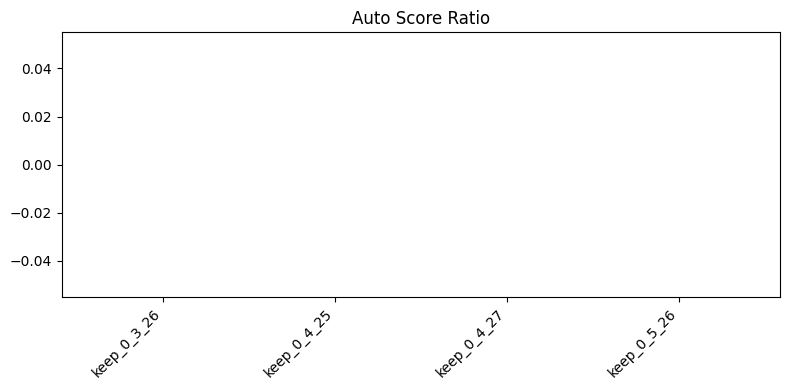

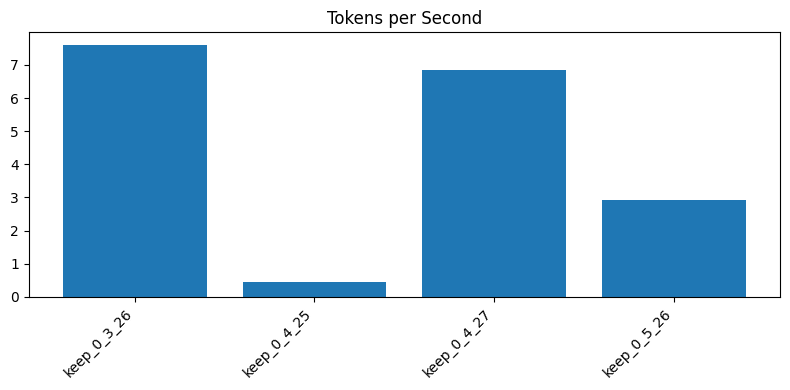

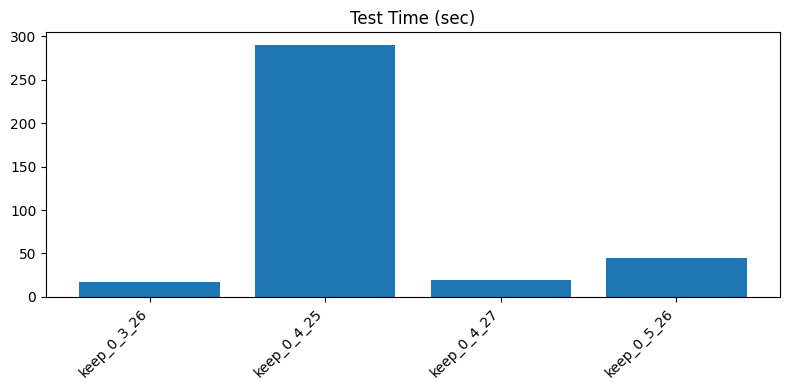

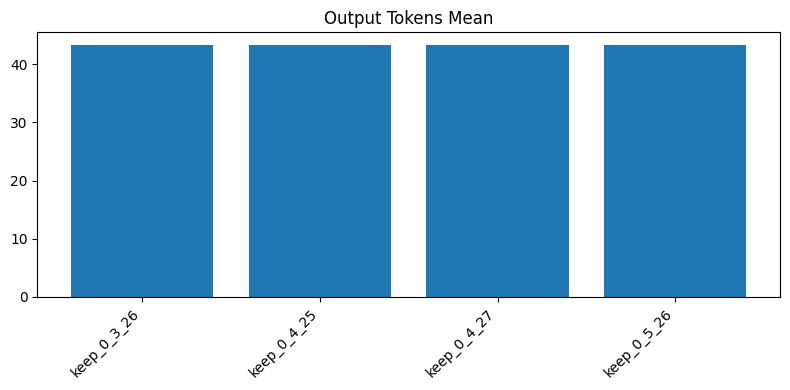

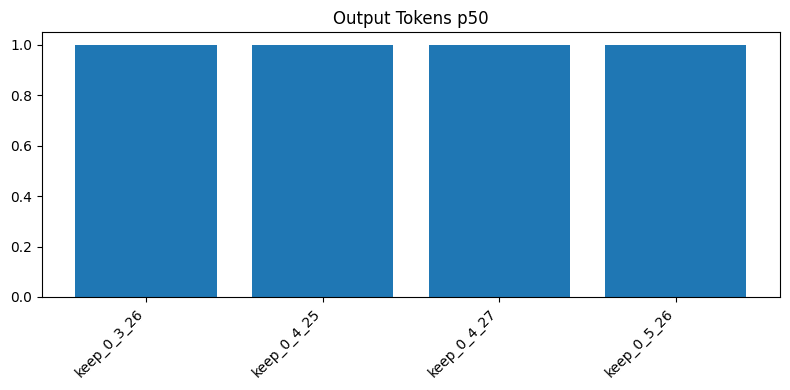

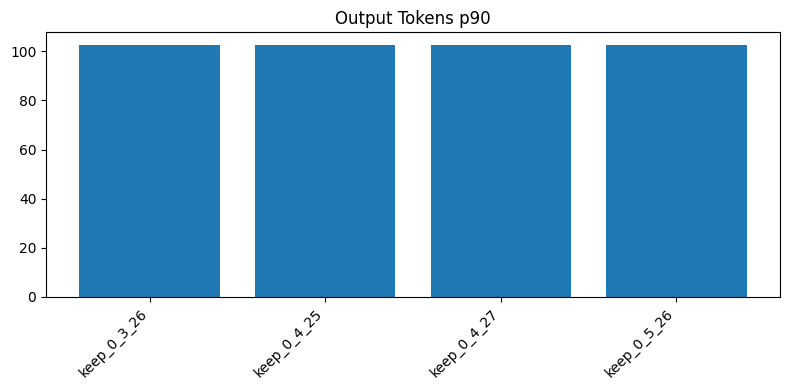

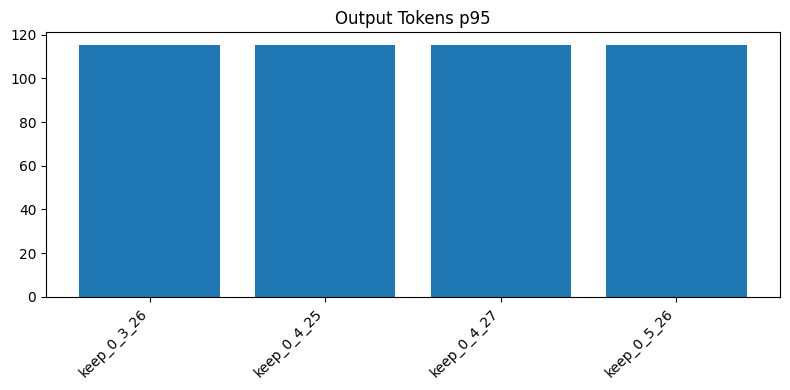

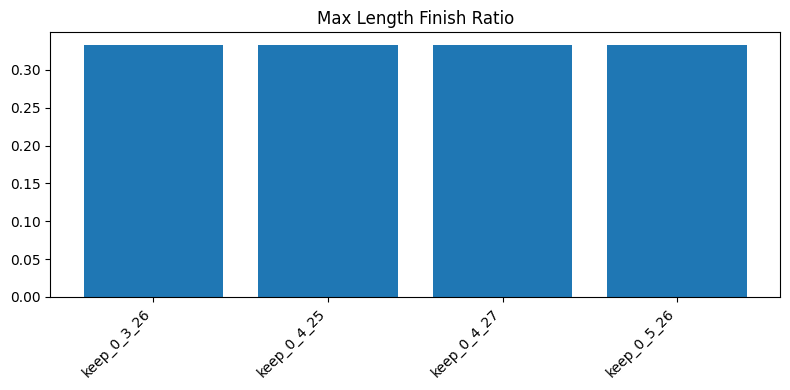

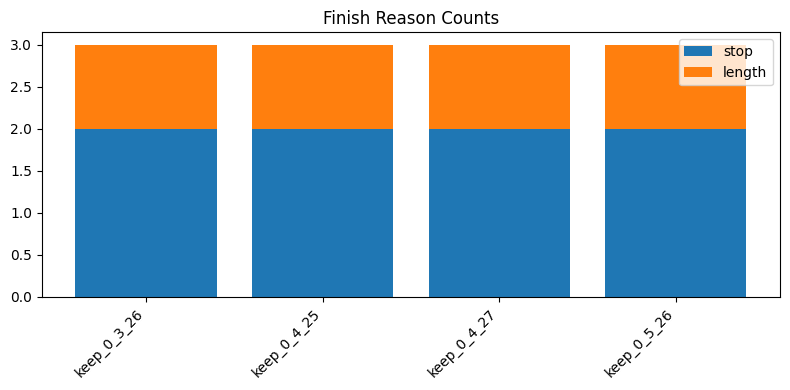

In [10]:
# Summary table
cols = ['name','auto_score_ratio','auto_score_total','auto_score_count','test_time_sec','tok_per_sec','out_tok_mean','out_tok_p50','out_tok_p90','out_tok_p95','max_length_finish_ratio']
bench_df[cols]

# Visualizations
import matplotlib.pyplot as plt
metrics = [
    ('auto_score_ratio', 'Auto Score Ratio'),
    ('tok_per_sec', 'Tokens per Second'),
    ('test_time_sec', 'Test Time (sec)'),
    ('out_tok_mean', 'Output Tokens Mean'),
    ('out_tok_p50', 'Output Tokens p50'),
    ('out_tok_p90', 'Output Tokens p90'),
    ('out_tok_p95', 'Output Tokens p95'),
    ('max_length_finish_ratio', 'Max Length Finish Ratio'),
]
for key, title in metrics:
    if key not in bench_df.columns:
        continue
    plt.figure(figsize=(8, 4))
    plt.bar(bench_df['name'], bench_df[key])
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# finish_reason_counts: stacked bar
if 'finish_reason_counts' in bench_df.columns:
    fr = bench_df['finish_reason_counts'].apply(lambda x: x or {})
    lengths = fr.apply(lambda d: d.get('length', 0))
    stops = fr.apply(lambda d: d.get('stop', 0))
    plt.figure(figsize=(8, 4))
    plt.bar(bench_df['name'], stops, label='stop')
    plt.bar(bench_df['name'], lengths, bottom=stops, label='length')
    plt.title('Finish Reason Counts')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()